# TP4 — Transformers : fine-tuning pour la classification de texte
**Projet de fin de module — Deep Learning**

Objectif : adapter un modèle **Transformer pré-entraîné** (DistilBERT) à une tâche de
**classification d'émotions** sur des messages courts, en suivant le chapitre 2 du
livre *Natural Language Processing with Transformers*.
Jeu de données : **emotion** (Hugging Face), 6 classes
(*sadness, joy, love, anger, fear, surprise*).

> Exécuter sur Google Colab avec un **GPU T4** (le fine-tuning prend quelques minutes).

## 0. Installation et imports

In [1]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers", "datasets", "scikit-learn"])

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_scheduler)
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

import os, warnings
warnings.filterwarnings("ignore")
os.makedirs("figs", exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device :", device)

CHECKPOINT = "distilbert-base-uncased"
EPOCHS     = 3
BATCH      = 64
LR         = 2e-5
torch.manual_seed(42)

Device : cuda


## 1. Chargement du jeu de données *emotion*

In [2]:
try:
    ds = load_dataset("dair-ai/emotion")
except Exception:
    ds = load_dataset("emotion")

labels = ds["train"].features["label"].names
num_labels = len(labels)
print("Classes :", labels)
print(ds)

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Classes : ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


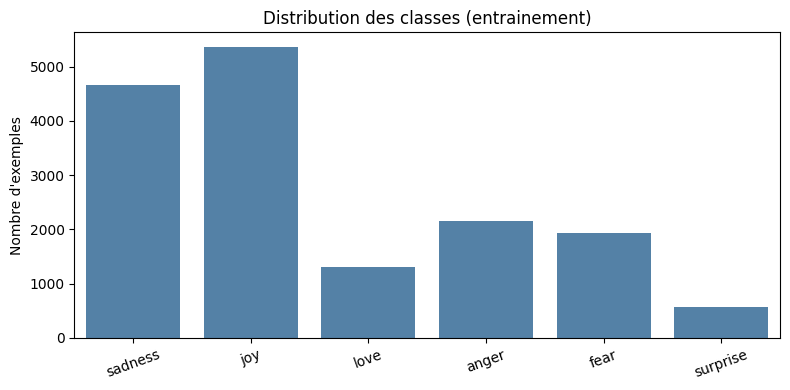

In [3]:
# Distribution des classes (figure : figs/tp4_label_dist.png)
counts = np.bincount(ds["train"]["label"], minlength=num_labels)
plt.figure(figsize=(8, 4))
sns.barplot(x=labels, y=counts, color="steelblue")
plt.title("Distribution des classes (entrainement)")
plt.ylabel("Nombre d'exemples"); plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("figs/tp4_label_dist.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Tokenisation
DistilBERT utilise un tokeniseur **WordPiece**. On tronque les textes trop longs ;
le *padding* dynamique est géré par lot via `DataCollatorWithPadding`.

In [4]:
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=128)

ds_enc = ds.map(tokenize, batched=True)
ds_enc = ds_enc.remove_columns(["text"]).rename_column("label", "labels")
# NB : on NE fait PAS ds_enc.set_format("torch"). Cela contourne une incompatibilite
# datasets/torchvision sur Colab (le formateur torch de datasets tente d'importer
# torchvision.io.VideoReader). La conversion en tenseurs est faite dans collate_fn.

def collate_fn(features):
    labels = torch.tensor([f["labels"] for f in features], dtype=torch.long)
    batch = tokenizer.pad(
        {"input_ids":      [f["input_ids"]      for f in features],
         "attention_mask": [f["attention_mask"] for f in features]},
        padding=True, return_tensors="pt")
    batch["labels"] = labels
    return batch

train_loader = DataLoader(ds_enc["train"],      batch_size=BATCH, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(ds_enc["validation"], batch_size=BATCH, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(ds_enc["test"],       batch_size=BATCH, shuffle=False, collate_fn=collate_fn)
print("Exemple de lot :", {k: v.shape for k, v in next(iter(train_loader)).items()})

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Exemple de lot : {'input_ids': torch.Size([64, 59]), 'attention_mask': torch.Size([64, 59]), 'labels': torch.Size([64])}


## 3. Modèle et fine-tuning
On charge DistilBERT avec une **tête de classification** à 6 sorties (initialisée
aléatoirement) ; tout le réseau est ensuite affiné (fine-tuning complet) avec un
faible taux d'apprentissage.

In [5]:
model = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT, num_labels=num_labels).to(device)

optimizer = AdamW(model.parameters(), lr=LR)
num_steps = EPOCHS * len(train_loader)
scheduler = get_scheduler("linear", optimizer=optimizer,
                          num_warmup_steps=0, num_training_steps=num_steps)

def evaluate(model, loader):
    model.eval()
    preds, gold = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds.append(logits.argmax(-1).cpu())
            gold.append(batch["labels"].cpu())
    p = torch.cat(preds).numpy(); g = torch.cat(gold).numpy()
    return accuracy_score(g, p), f1_score(g, p, average="weighted"), g, p

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
hist = {"train_loss": [], "val_acc": [], "val_f1": []}
for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        out.loss.backward()
        optimizer.step(); scheduler.step()
        running += out.loss.item()
    acc, f1, _, _ = evaluate(model, val_loader)
    hist["train_loss"].append(running / len(train_loader))
    hist["val_acc"].append(acc); hist["val_f1"].append(f1)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss {running/len(train_loader):.4f} "
          f"| val_acc {acc:.4f} | val_f1 {f1:.4f}")

Epoch 1/3 | train_loss 0.7818 | val_acc 0.9160 | val_f1 0.9160
Epoch 2/3 | train_loss 0.2026 | val_acc 0.9280 | val_f1 0.9282
Epoch 3/3 | train_loss 0.1393 | val_acc 0.9235 | val_f1 0.9239


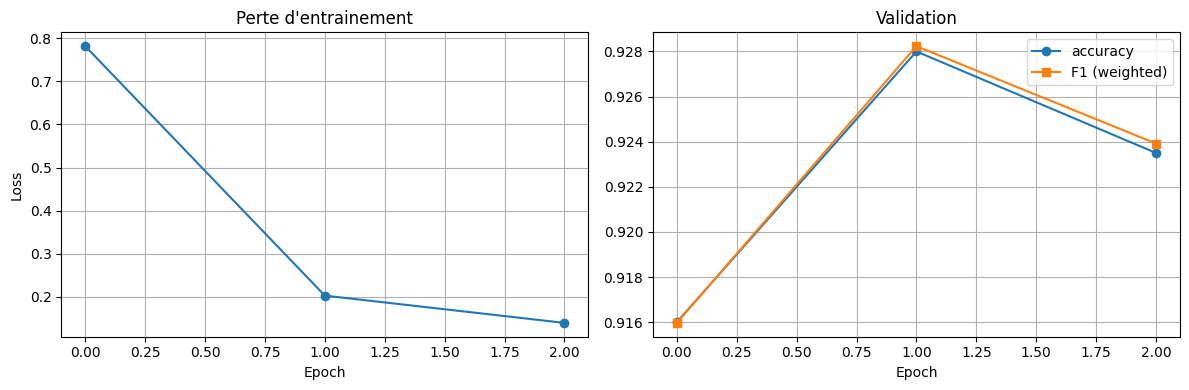

In [7]:
# Courbes d'entrainement (figure : figs/tp4_training.png)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], marker="o"); ax[0].set_title("Perte d'entrainement")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].grid(True)
ax[1].plot(hist["val_acc"], marker="o", label="accuracy")
ax[1].plot(hist["val_f1"],  marker="s", label="F1 (weighted)")
ax[1].set_title("Validation"); ax[1].set_xlabel("Epoch"); ax[1].legend(); ax[1].grid(True)
plt.tight_layout()
plt.savefig("figs/tp4_training.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Évaluation sur l'ensemble de test

In [8]:
acc, f1, g, p = evaluate(model, test_loader)
print(f"Test accuracy : {acc:.4f}")
print(f"Test F1 (weighted) : {f1:.4f}\n")
print(classification_report(g, p, target_names=labels))

import pandas as pd
pd.DataFrame({"accuracy": [acc], "f1_weighted": [f1]}).to_csv(
    "figs/tp4_results.csv", index=False)

Test accuracy : 0.9195
Test F1 (weighted) : 0.9200

              precision    recall  f1-score   support

     sadness       0.95      0.97      0.96       581
         joy       0.96      0.93      0.94       695
        love       0.78      0.89      0.83       159
       anger       0.93      0.89      0.91       275
        fear       0.88      0.88      0.88       224
    surprise       0.74      0.74      0.74        66

    accuracy                           0.92      2000
   macro avg       0.87      0.88      0.88      2000
weighted avg       0.92      0.92      0.92      2000



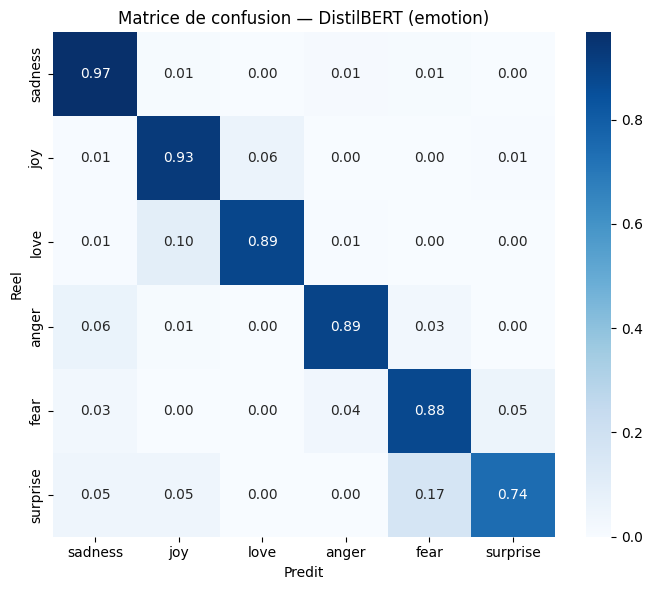

In [9]:
# Matrice de confusion normalisee (figure : figs/tp4_confusion.png)
cm = confusion_matrix(g, p)
cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predit"); plt.ylabel("Reel"); plt.title("Matrice de confusion — DistilBERT (emotion)")
plt.tight_layout()
plt.savefig("figs/tp4_confusion.png", dpi=200, bbox_inches="tight")
plt.show()

## 5. Test sur des phrases personnalisées

In [10]:
def predict(texts):
    model.eval()
    enc = tokenizer(texts, truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        pred = model(**enc).logits.argmax(-1).cpu().numpy()
    return [labels[i] for i in pred]

examples = [
    "I can't believe this happened, I'm so happy!",
    "I'm really scared about the exam tomorrow.",
    "Why did you do that? I'm furious.",
]
for t, e in zip(examples, predict(examples)):
    print(f"[{e:8s}] {t}")

[joy     ] I can't believe this happened, I'm so happy!
[fear    ] I'm really scared about the exam tomorrow.
[anger   ] Why did you do that? I'm furious.
